In [1]:
import sys
import os
sys.path.append(os.path.abspath('../../..'))
from src.models.n_gram_network import Tokenizer, NGramNetwork
import matplotlib.pyplot as plt
import numpy
import time
%matplotlib inline

**Summary:**

Best batch size is around 64.

In [2]:
# Initializations for network

data_path = '../../../src/data/normalized/en_cities.txt'
tokenizer = Tokenizer(data_path)

In [3]:
n = 32000 # the total number of values used in training
i = 1

batch_sizes = []
losses = []
times = []

for batch_size in range(1, 256):
    start = time.perf_counter()
    
    print(f'iter {i:>4}')
    iterations = n // batch_size
    
    network = NGramNetwork(4, tokenizer, data_path, embedding_vector_size=8, w1_out=256)
    network.train(batch_size, iterations, print_out=False)
    
    elapsed = time.perf_counter() - start
    
    batch_sizes.append(batch_size)
    losses.append(network.evaluate_test_set())
    times.append(elapsed)
    
    i += 1

iter    1
iter    2
iter    3
iter    4
iter    5
iter    6
iter    7
iter    8
iter    9
iter   10
iter   11
iter   12
iter   13
iter   14
iter   15
iter   16
iter   17
iter   18
iter   19
iter   20
iter   21
iter   22
iter   23
iter   24
iter   25
iter   26
iter   27
iter   28
iter   29
iter   30
iter   31
iter   32
iter   33
iter   34
iter   35
iter   36
iter   37
iter   38
iter   39
iter   40
iter   41
iter   42
iter   43
iter   44
iter   45
iter   46
iter   47
iter   48
iter   49
iter   50
iter   51
iter   52
iter   53
iter   54
iter   55
iter   56
iter   57
iter   58
iter   59
iter   60
iter   61
iter   62
iter   63
iter   64
iter   65
iter   66
iter   67
iter   68
iter   69
iter   70
iter   71
iter   72
iter   73
iter   74
iter   75
iter   76
iter   77
iter   78
iter   79
iter   80
iter   81
iter   82
iter   83
iter   84
iter   85
iter   86
iter   87
iter   88
iter   89
iter   90
iter   91
iter   92
iter   93
iter   94
iter   95
iter   96
iter   97
iter   98
iter   99
iter  100


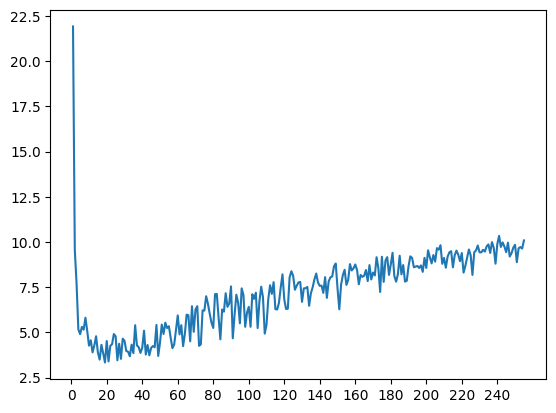

In [4]:
plt.plot(batch_sizes, losses)
plt.xticks( numpy.arange( 0, 256, 20 ) )
plt.show()

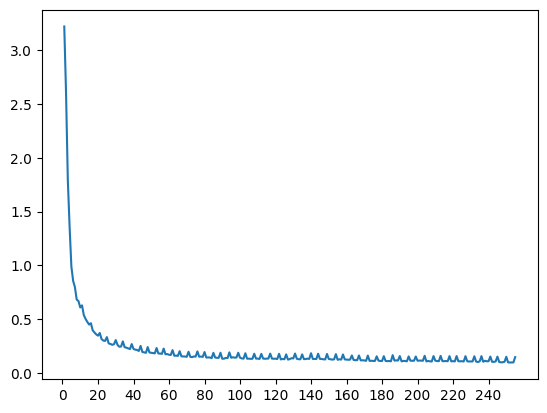

In [5]:
plt.plot(batch_sizes, times)
plt.xticks( numpy.arange( 0, 256, 20 ) )
plt.show()

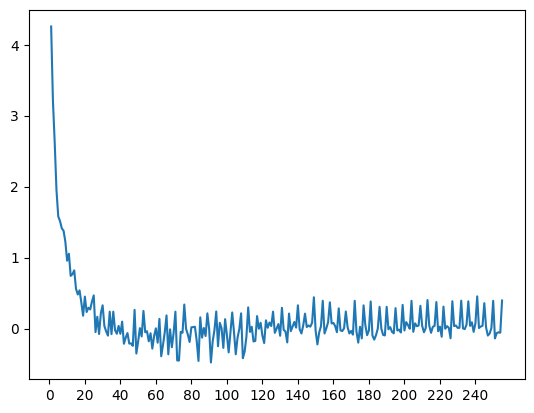

In [6]:
# I want the loswest time * loss

ls = numpy.array(losses)
ts = numpy.array(times)

x = numpy.log(ls * ts)

plt.plot(batch_sizes, x)
plt.xticks( numpy.arange( 0, 256, 20 ) )
plt.show()


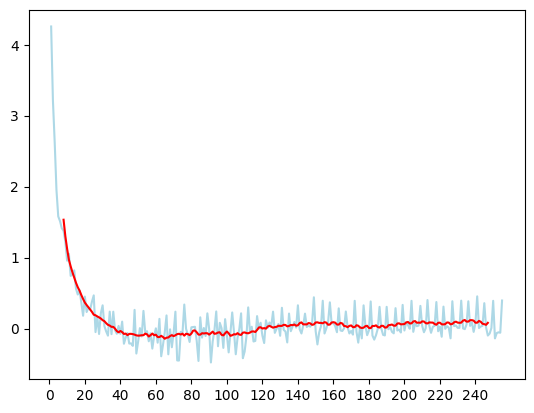

In [7]:
# Smoothed out with moving window approach:

window_size = 16

cut_start = (window_size-1) // 2
cut_end = window_size - 1 - cut_start

x_smoothed = numpy.convolve(x, numpy.ones(window_size) / window_size, mode='valid')

plt.plot(batch_sizes, x, color='lightblue')
plt.plot(batch_sizes[cut_start: -cut_end], x_smoothed, color='red')
plt.xticks( numpy.arange( 0, 256, 20 ) )
plt.show()

In [8]:
# Original noisy minimum
print('Index', numpy.argmin(x))
print('Value', min(x))

Index 90
Value -0.4783573542386585


In [9]:
# Smoothed out minimum
print('Index', numpy.argmin(x_smoothed) + cut_start)
print('Value', min(x_smoothed))

Index 64
Value -0.1436578056307541



Smoothed out minimums:
- idx 94, val -0.2
- idx 62, val -0.18
- idx 81, val -0.32
- idx 64, val -0.14

This last graph is the smoothest so far,
and I think it is pretty obvious from it
that the best batch size should be around 64.